# CREATING TOKEN EMBEDDINGS

How the token ID to embedding vector conversion works with a hands-on example. Suppose we have the following four input token id's.

In [2]:
!pip install torch

In [4]:
import torch
input_ids = torch.tensor([2,3,5,1])

Suppose we have a small vocabulary of only 6 words (instead of the 50,257 words in the BPE tokenizer vocabulary), and we want to create embeddings of size 3(in GPT-3, the embedding size is 12,388 dimensions):

Using the vocab_size and output_dim, we can instantiate an embedding layer in PyTorch, setting the random seed to 123 for reproducibility purpose

In [5]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

Lets print the embedding_layer that should output the weighted matrix

In [6]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


We can see that the weight matrix of the embedding layer contains small, random values. These values are optimized during LLm training as part of the LLM optimization itself, as we will see in upcoming chapters. Moreover, we can see that the weight matrix has six rows and three columns. There is one row for each of the six possible tokens in the vocabulary. And there is one column for each of the three embedding dimensions.

After we instantiated the embedding layer, lets now apply it to a token ID to obtain the embedding vector:

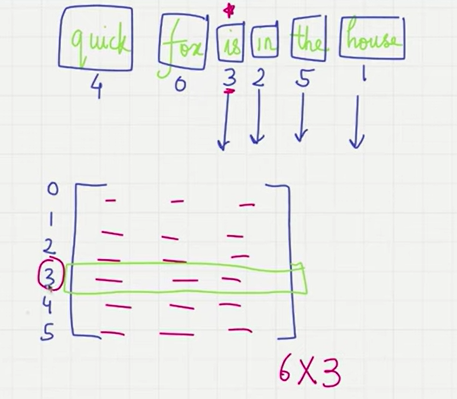

in the above for selecting "is" we need to look into the token id correspondint to it "3". Then in the weighted matrix we need to look into the vector embeddings corresponding to that token id. This is why it is called a lookup table.

In [11]:
print(embedding_layer(torch.tensor(3)))

tensor([-0.4015,  0.9666, -1.1481], grad_fn=<EmbeddingBackward0>)


If we compare the embedding vector for token ID 3 to the previous embedding matrix, we see that it is identical to the 4th row (python starts with a zero index, so its the row corresponding to index 3), In other words, the embedding layeris essentially a lookup operation that retrieves rows from the embedding layer's weight matrix via a token ID.

In [8]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


The embedding layer is a lookup operation that retrieves rows from the embedding layer weight matrix using a token ID.

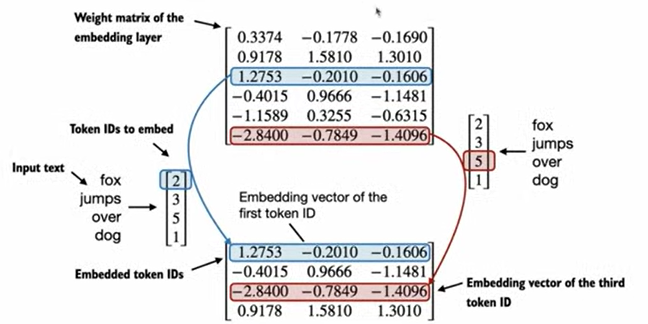

The above embedding layer is the same as Neural network linear layer

# Neural N/W output is same as Embedding layer output


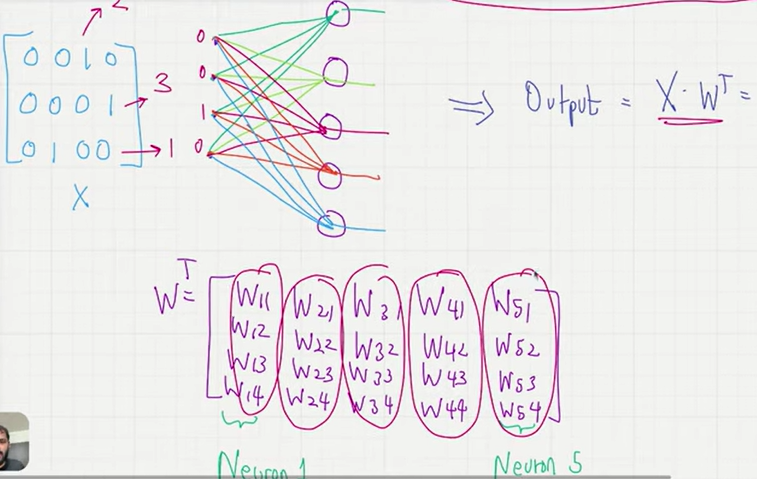

Both embedding layer and NN linear layer lead to same output

Embedding layer is much more computationally efficient, since NN linear layer has many unnecessary multiplications with zero. For example if we look at the matrix before the NN in blue colour we could see that we need to perform one-hot encoding and then feed it to the neurons. But in the Embedding layer we dont have to do this we just need to compute the [X*(W)^T]